In [1]:
# =====================================================
# CELL 1 — IMPORT THƯ VIỆN
# =====================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.size'] = 11
print("Import xong!")

Import xong!


In [2]:
# =====================================================
# CELL 2 — ĐỌC DỮ LIỆU
# =====================================================

df = pd.read_csv('../data/processed/processed_retail_data.csv')

feature_cols = [
    'total_sales', 'sale_frequency', 'revenue',
    'sales_variance', 'avg_inventory',
    'stock_turnover', 'fill_rate',
]

X = df[feature_cols].values

print("Shape:", df.shape)
print("Features:", feature_cols)
print(df.head())

Shape: (100, 9)
Features: ['total_sales', 'sale_frequency', 'revenue', 'sales_variance', 'avg_inventory', 'stock_turnover', 'fill_rate']
  product_id store_id  total_sales  sale_frequency   revenue  sales_variance  \
0      P0001     S001     0.507692        0.529877  0.615450        0.302068   
1      P0001     S002     1.960491        0.529877  1.201130        2.229965   
2      P0001     S003    -1.426686       -0.075697 -0.915182       -0.854018   
3      P0001     S004     0.201317       -0.378484  0.174873        0.426690   
4      P0001     S005    -1.487775       -0.681271 -1.640923       -1.400992   

   avg_inventory  stock_turnover  fill_rate  
0      -0.136901        0.771656  -1.759228  
1       0.704933        1.969950   1.666613  
2       0.085058       -1.919924  -0.222167  
3      -0.810170        0.915664  -0.516193  
4      -1.185478       -1.027251  -1.174525  


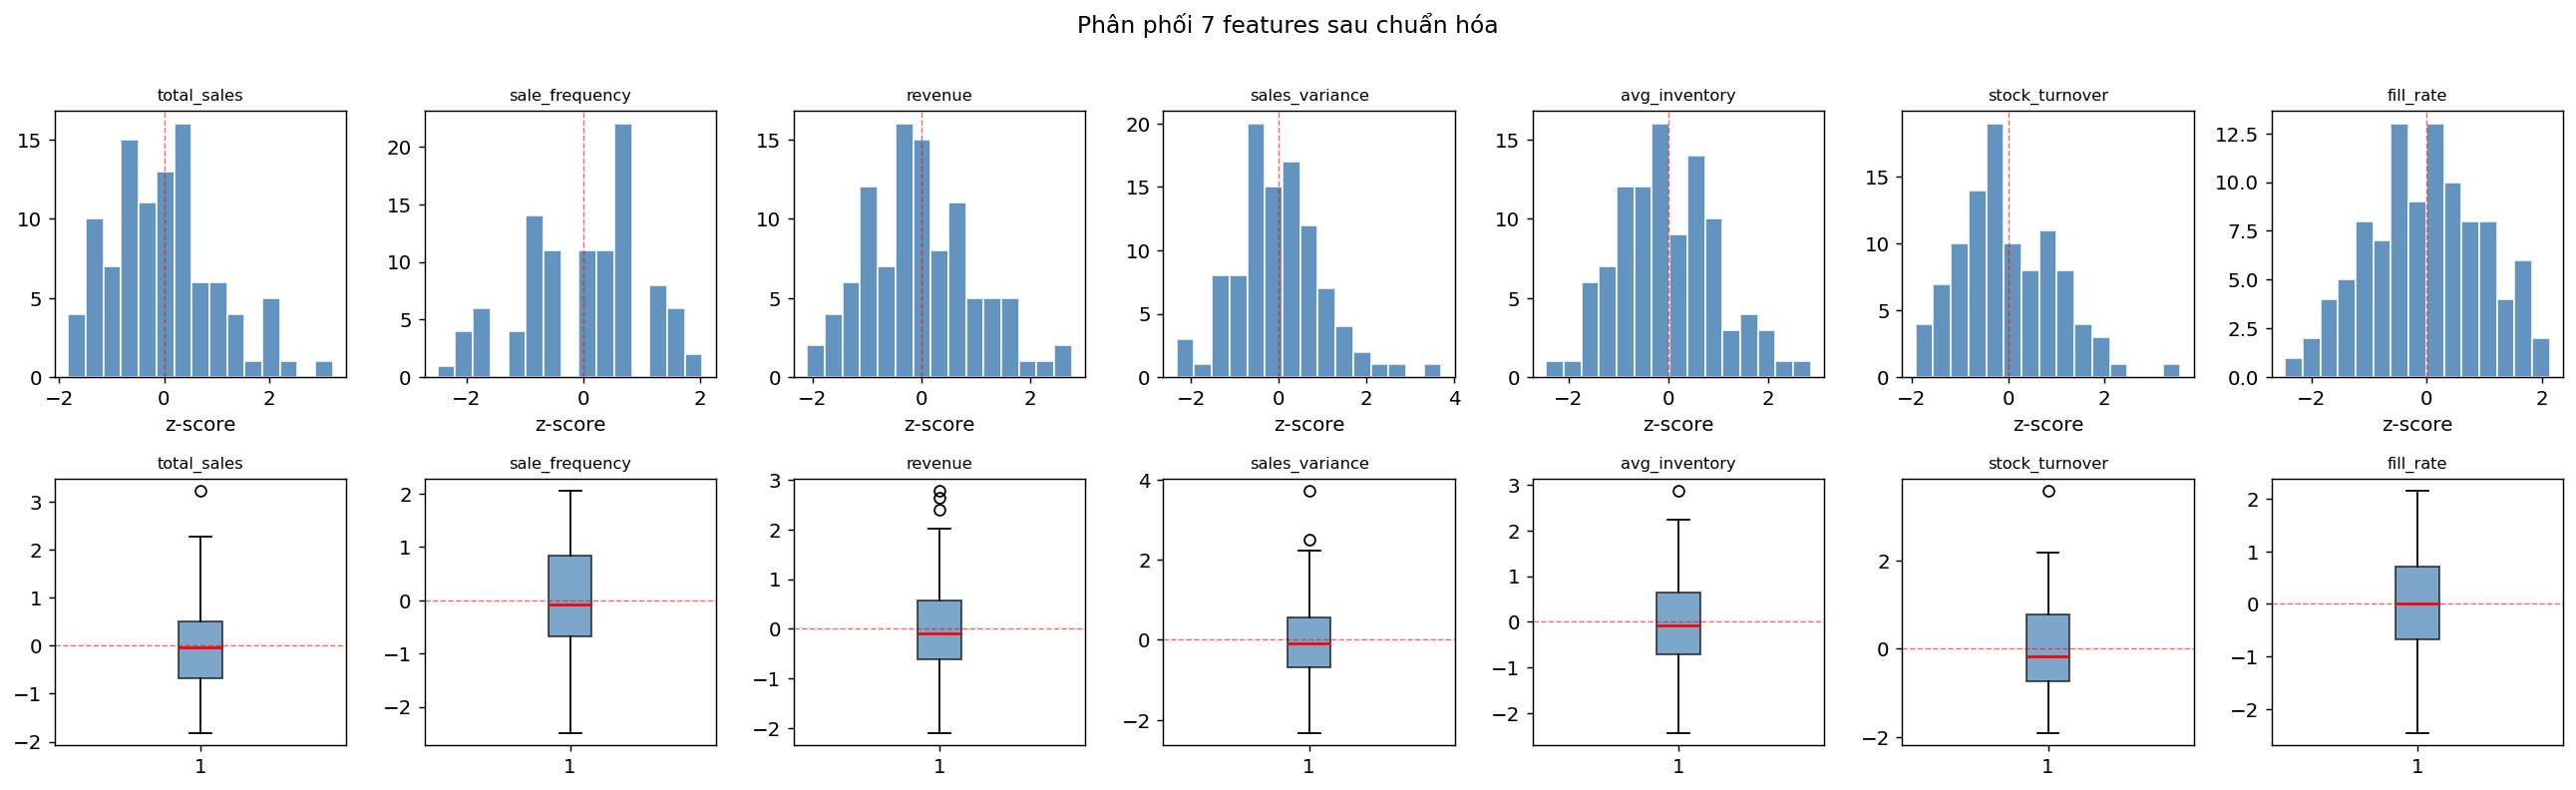

In [3]:
# =====================================================
# CELL 3 — PHÂN TÍCH PHÂN PHỐI FEATURE
# Biểu đồ: histogram + boxplot từng feature
# =====================================================

fig, axes = plt.subplots(2, 7, figsize=(20, 6))
fig.suptitle('Phân phối 7 features sau chuẩn hóa', fontsize=13, y=1.01)

for i, col in enumerate(feature_cols):
    # Histogram
    axes[0, i].hist(df[col], bins=15, color='steelblue', edgecolor='white', alpha=0.85)
    axes[0, i].set_title(col, fontsize=9)
    axes[0, i].set_xlabel('z-score')
    axes[0, i].axvline(0, color='red', linestyle='--', linewidth=0.8, alpha=0.6)

    # Boxplot
    axes[1, i].boxplot(df[col], patch_artist=True,
                       boxprops=dict(facecolor='steelblue', alpha=0.7),
                       medianprops=dict(color='red', linewidth=1.5))
    axes[1, i].set_title(col, fontsize=9)
    axes[1, i].axhline(0, color='red', linestyle='--', linewidth=0.8, alpha=0.6)

plt.tight_layout()
plt.savefig('../reports/feature_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

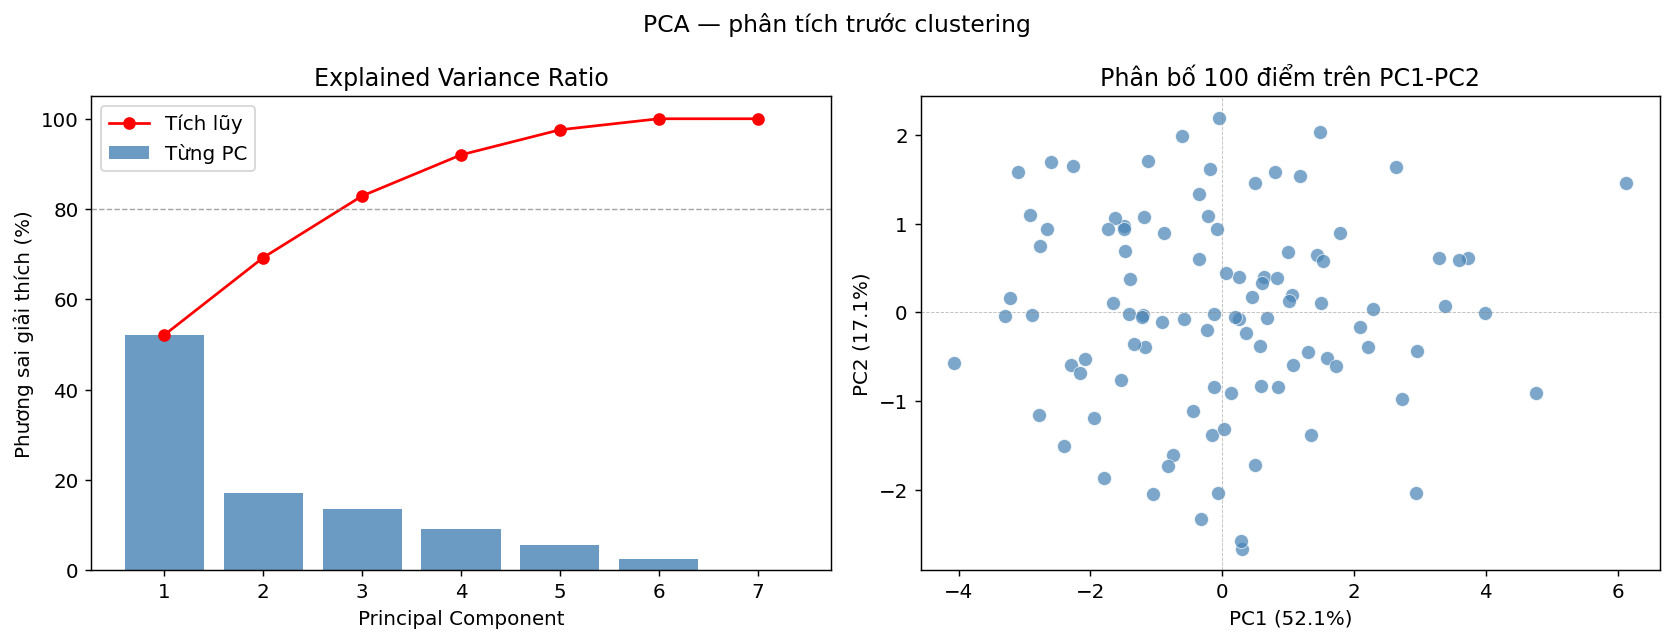

PC1+PC2 giải thích: 69.3% tổng phương sai


In [4]:
# =====================================================
# CELL 4 — PCA VISUALIZATION (trước clustering)
# Biểu đồ: scatter 2D, explained variance
# =====================================================

pca = PCA()
X_pca_full = pca.fit_transform(X)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('PCA — phân tích trước clustering', fontsize=13)

# Explained variance
axes[0].bar(range(1, 8), explained * 100, color='steelblue', alpha=0.8, label='Từng PC')
axes[0].plot(range(1, 8), cumulative * 100, 'ro-', linewidth=1.5, label='Tích lũy')
axes[0].axhline(80, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Phương sai giải thích (%)')
axes[0].set_title('Explained Variance Ratio')
axes[0].legend()
axes[0].set_xticks(range(1, 8))

# PC1 vs PC2
axes[1].scatter(X_pca_full[:, 0], X_pca_full[:, 1],
                c='steelblue', alpha=0.7, s=60, edgecolors='white', linewidth=0.5)
axes[1].set_xlabel(f'PC1 ({explained[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({explained[1]*100:.1f}%)')
axes[1].set_title('Phân bố 100 điểm trên PC1-PC2')
axes[1].axhline(0, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
axes[1].axvline(0, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.savefig('../reports/pca_before_clustering.png', dpi=150)
plt.show()

print(f"PC1+PC2 giải thích: {cumulative[1]*100:.1f}% tổng phương sai")

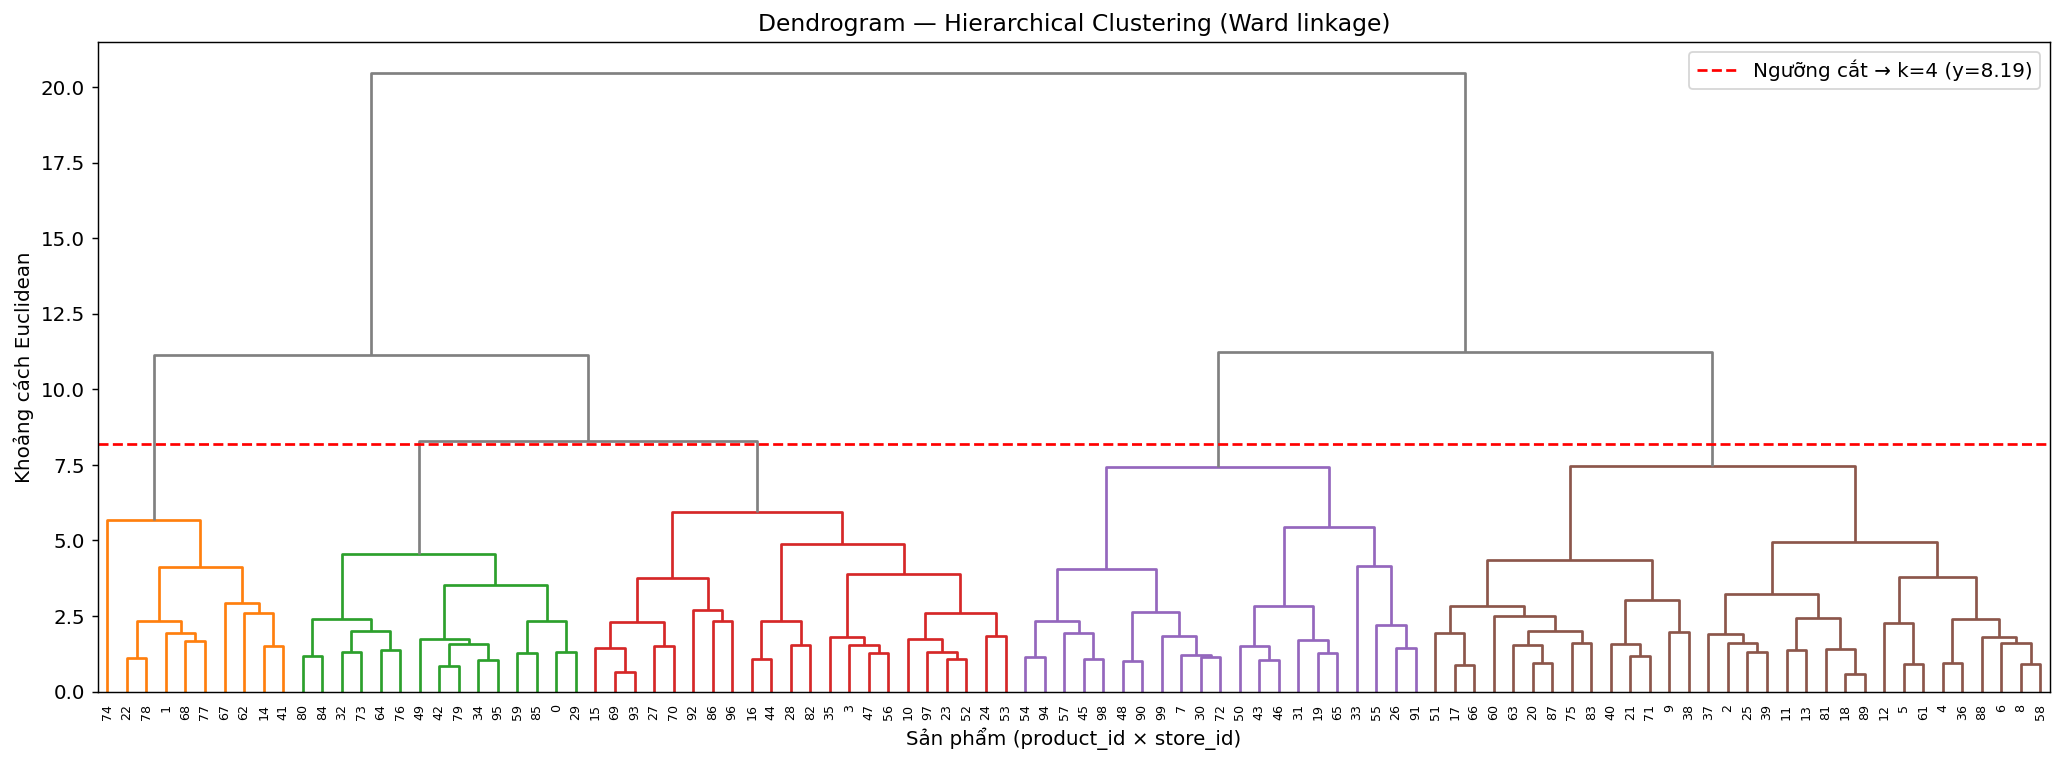

In [5]:

# =====================================================
# CELL 5 — DENDROGRAM
# Xác định số cụm bằng Hierarchical Clustering
# =====================================================

Z = linkage(X, method='ward', metric='euclidean')

fig, ax = plt.subplots(figsize=(16, 6))

dendrogram(
    Z,
    ax=ax,
    truncate_mode=None,
    color_threshold=0.4 * max(Z[:, 2]),
    above_threshold_color='gray',
    leaf_rotation=90,
    leaf_font_size=7,
)

# Vẽ đường cắt gợi ý k=4
threshold = 0.4 * max(Z[:, 2])
ax.axhline(y=threshold, color='red', linestyle='--', linewidth=1.5,
           label=f'Ngưỡng cắt → k=4 (y={threshold:.2f})')

ax.set_title('Dendrogram — Hierarchical Clustering (Ward linkage)', fontsize=13)
ax.set_xlabel('Sản phẩm (product_id × store_id)')
ax.set_ylabel('Khoảng cách Euclidean')
ax.legend()

plt.tight_layout()
plt.savefig('../reports/dendrogram.png', dpi=150)
plt.show()

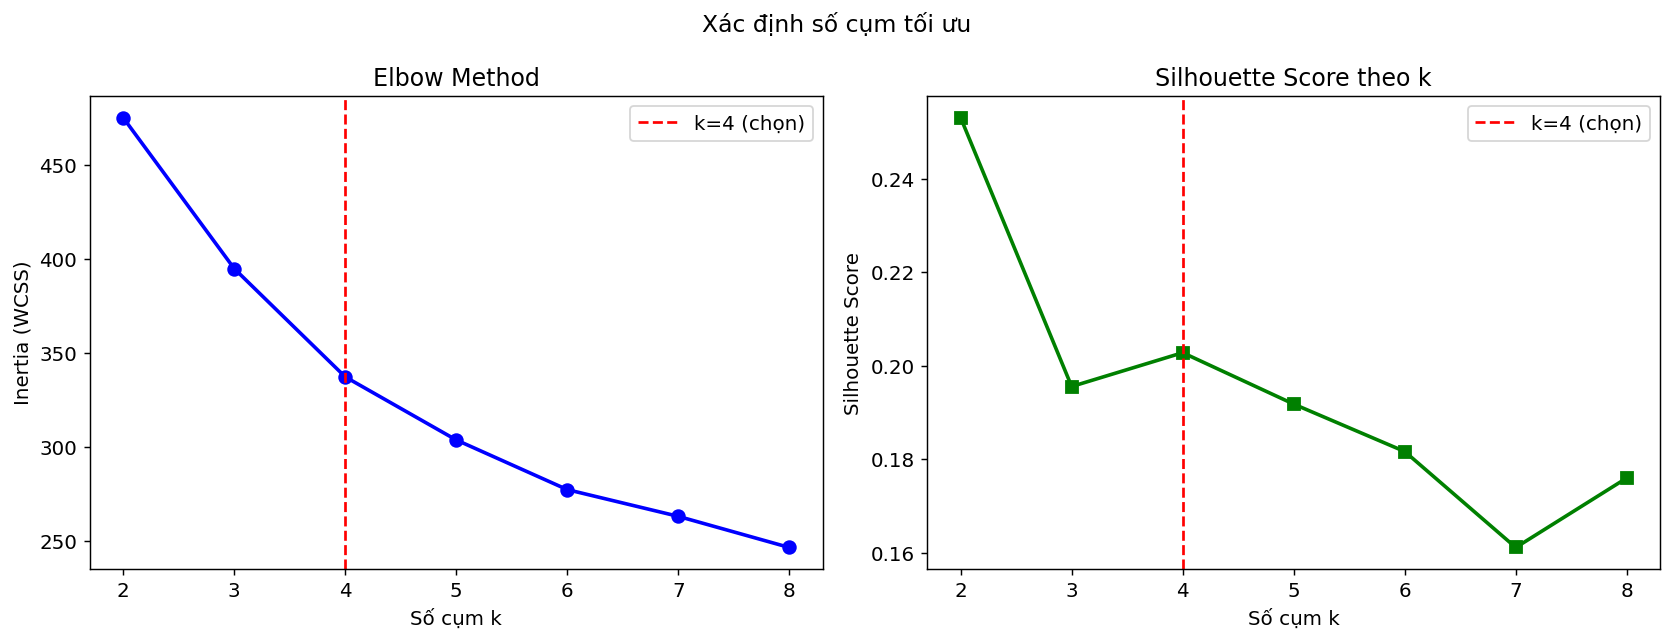

Silhouette cao nhất tại k=2: 0.2530
→ Chọn k=4 dựa trên Dendrogram + Elbow + Silhouette


In [6]:

# =====================================================
# CELL 6 — ELBOW METHOD + SILHOUETTE (KMeans)
# Xác định k tối ưu có căn cứ số liệu
# =====================================================

k_range = range(2, 9)
inertias, sil_scores = [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Xác định số cụm tối ưu', fontsize=13)

# Elbow
axes[0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=7)
axes[0].axvline(x=4, color='red', linestyle='--', linewidth=1.5, label='k=4 (chọn)')
axes[0].set_xlabel('Số cụm k')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Elbow Method')
axes[0].set_xticks(list(k_range))
axes[0].legend()

# Silhouette
axes[1].plot(k_range, sil_scores, 'gs-', linewidth=2, markersize=7)
axes[1].axvline(x=4, color='red', linestyle='--', linewidth=1.5, label='k=4 (chọn)')
axes[1].set_xlabel('Số cụm k')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score theo k')
axes[1].set_xticks(list(k_range))
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/elbow_silhouette.png', dpi=150)
plt.show()

best_k = k_range[sil_scores.index(max(sil_scores))]
print(f"Silhouette cao nhất tại k={best_k}: {max(sil_scores):.4f}")
print("→ Chọn k=4 dựa trên Dendrogram + Elbow + Silhouette")

In [7]:
# =====================================================
# CELL 7 — HIERARCHICAL CLUSTERING (k=4)
# =====================================================

hc_model = AgglomerativeClustering(n_clusters=4, linkage='ward')
df['Cluster_HC'] = hc_model.fit_predict(X)

print("Hierarchical Clustering — phân bố cụm:")
print(df['Cluster_HC'].value_counts().sort_index())


Hierarchical Clustering — phân bố cụm:
Cluster_HC
0    37
1    32
2    21
3    10
Name: count, dtype: int64


In [8]:
# =====================================================
# CELL 8 — KMEANS (k=4)
# =====================================================

km_model = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster_KM'] = km_model.fit_predict(X)

print("KMeans — phân bố cụm:")
print(df['Cluster_KM'].value_counts().sort_index())

KMeans — phân bố cụm:
Cluster_KM
0    27
1    14
2    23
3    36
Name: count, dtype: int64



Đặc trưng trung bình từng cụm (Hierarchical):
            total_sales  sale_frequency  revenue  sales_variance  \
Cluster_HC                                                         
0                 0.527           0.113    0.475           0.375   
1                -0.856           0.407   -0.591          -0.666   
2                -0.531          -1.056   -0.706          -0.376   
3                 1.904           0.500    1.616           1.532   

            avg_inventory  stock_turnover  fill_rate  
Cluster_HC                                            
0                   0.282           0.472     -0.020  
1                  -0.672          -0.588     -0.794  
2                  -0.102          -0.609      0.723  
3                   1.318           1.414      1.095  


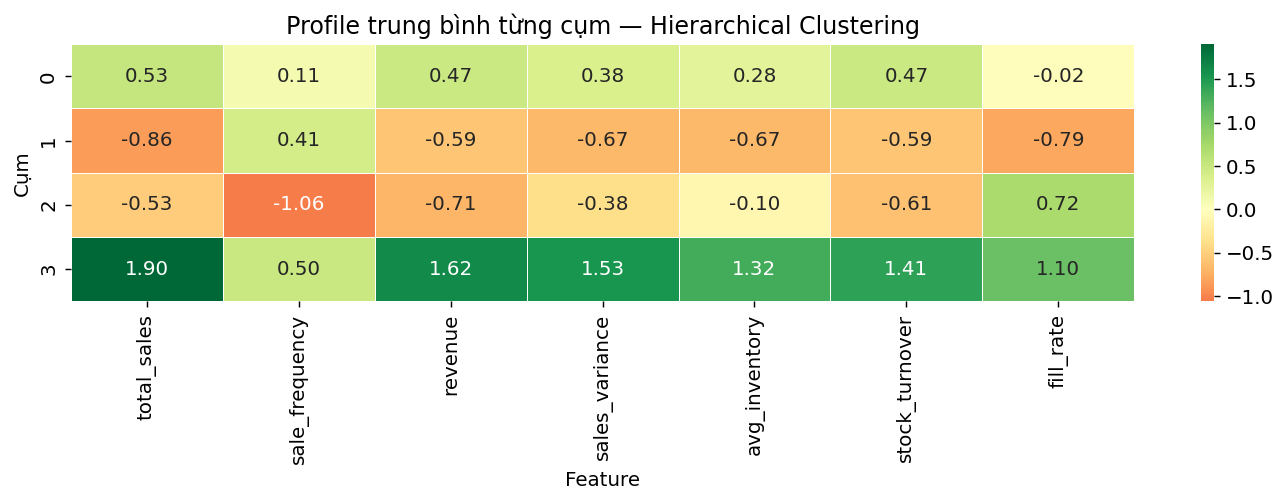

In [9]:
# =====================================================
# CELL 9 — ĐẶC TRƯNG TRUNG BÌNH TỪNG CỤM (HC)
# Biểu đồ: heatmap cluster profile
# =====================================================

cluster_profile = df.groupby('Cluster_HC')[feature_cols].mean()
print("\nĐặc trưng trung bình từng cụm (Hierarchical):")
print(cluster_profile.round(3))

# Heatmap profile
fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(
    cluster_profile,
    annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, linewidths=0.5, ax=ax
)
ax.set_title('Profile trung bình từng cụm — Hierarchical Clustering')
ax.set_xlabel('Feature')
ax.set_ylabel('Cụm')
plt.tight_layout()
plt.savefig('../reports/cluster_profile_hc.png', dpi=150)
plt.show()

In [17]:
#  =====================================================
# CELL 10 — ĐẶT TÊN CỤM DỰA TRÊN PROFILE
# =====================================================

# Đọc profile để đặt tên
# Cụm có total_sales + revenue cao nhất → bán chạy
# Cụm có avg_inventory cao, stock_turnover thấp → tồn kho cao
# Cụm có fill_rate thấp, total_sales thấp → bán chậm
# Còn lại → ổn định

profile_sorted = cluster_profile.copy()

# Xếp hạng từng cụm theo từng tiêu chí
rank_sales = cluster_profile['total_sales'].rank(ascending=False)
rank_inv   = cluster_profile['avg_inventory'].rank(ascending=False)
rank_fill  = cluster_profile['fill_rate'].rank(ascending=True)   # thấp = chậm

# Gán nhãn: mỗi cụm chỉ nhận 1 nhãn, ưu tiên theo thứ tự
assigned = {}
used_clusters = set()

for label, rank_series in [
    ('Bán chạy',    rank_sales),
    ('Tồn kho cao', rank_inv),
    ('Bán chậm',    rank_fill),
]:
    # Lấy cụm xếp hạng 1 chưa được gán
    for cid in rank_series.sort_values().index:
        if cid not in used_clusters:
            assigned[cid] = label
            used_clusters.add(cid)
            break

# Cụm còn lại → Ổn định
for cid in cluster_profile.index:
    if cid not in assigned:
        assigned[cid] = 'Ổn định'

cluster_names = assigned
print("cluster_names:", cluster_names)

df['Cluster_Name'] = df['Cluster_HC'].map(cluster_names)

print("\nNhãn cụm:")
for k, v in cluster_names.items():
    print(f"  Cụm {k} → {v}: {(df['Cluster_HC']==k).sum()} điểm")

cluster_names: {3: 'Bán chạy', 0: 'Tồn kho cao', 1: 'Bán chậm', 2: 'Ổn định'}

Nhãn cụm:
  Cụm 3 → Bán chạy: 10 điểm
  Cụm 0 → Tồn kho cao: 37 điểm
  Cụm 1 → Bán chậm: 32 điểm
  Cụm 2 → Ổn định: 21 điểm


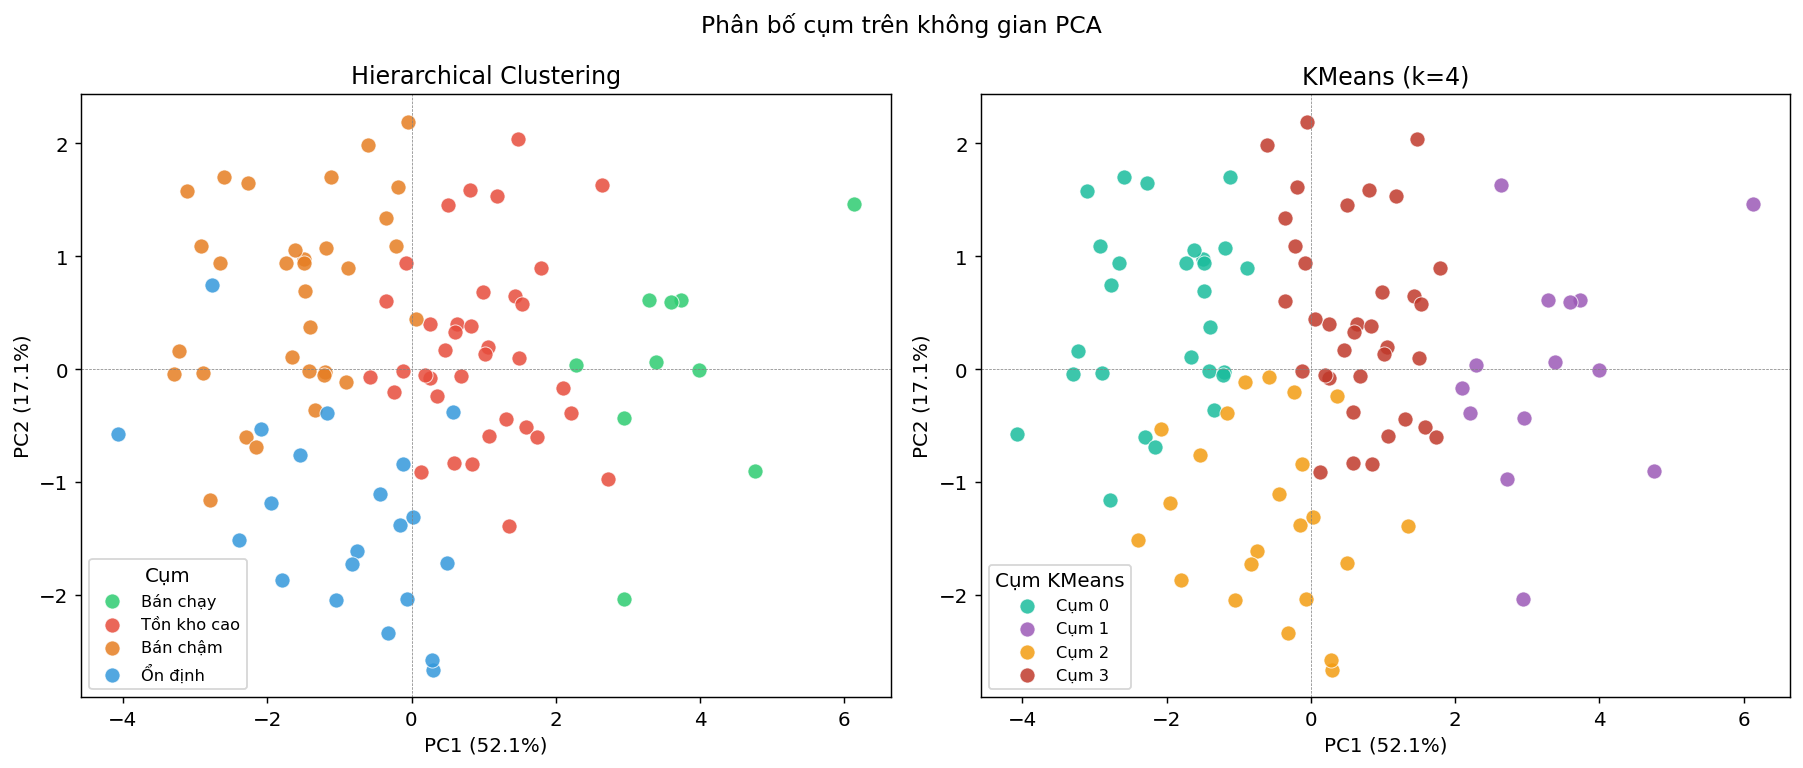

In [20]:
# =====================================================
# CELL 11 — SCATTER PLOT PHÂN BỐ CỤM (HC)
# Trên không gian PC1-PC2
#  =====================================================

pca2 = PCA(n_components=2)
X_2d = pca2.fit_transform(X)

colors = {
    'Bán chạy'   : '#2ecc71',
    'Tồn kho cao': '#e74c3c',
    'Bán chậm'   : '#e67e22',
    'Ổn định'    : '#3498db',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Phân bố cụm trên không gian PCA', fontsize=13)

for name, color in colors.items():
    mask = df['Cluster_Name'] == name
    axes[0].scatter(X_2d[mask, 0], X_2d[mask, 1],
                    c=color, label=name, s=70,
                    edgecolors='white', linewidth=0.5, alpha=0.85)

# HC
axes[0].set_title('Hierarchical Clustering')
axes[0].set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].legend(title='Cụm', fontsize=9)
axes[0].axhline(0, color='gray', linestyle='--', linewidth=0.4)
axes[0].axvline(0, color='gray', linestyle='--', linewidth=0.4)

# KMeans — tô màu theo từng cụm rời rạc
km_colors = ['#1abc9c', '#9b59b6', '#f39c12', '#c0392b']
km_labels = df['Cluster_KM'].values

for cid, color in zip(sorted(np.unique(km_labels)), km_colors):
    mask = km_labels == cid
    axes[1].scatter(X_2d[mask, 0], X_2d[mask, 1],
                    c=color, label=f'Cụm {cid}',
                    s=70, edgecolors='white', linewidth=0.5, alpha=0.85)

axes[1].set_title('KMeans (k=4)')
axes[1].set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].legend(title='Cụm KMeans', fontsize=9)
axes[1].axhline(0, color='gray', linestyle='--', linewidth=0.4)
axes[1].axvline(0, color='gray', linestyle='--', linewidth=0.4)

plt.tight_layout()
plt.savefig('../reports/cluster_scatter_pca.png', dpi=150)
plt.show()

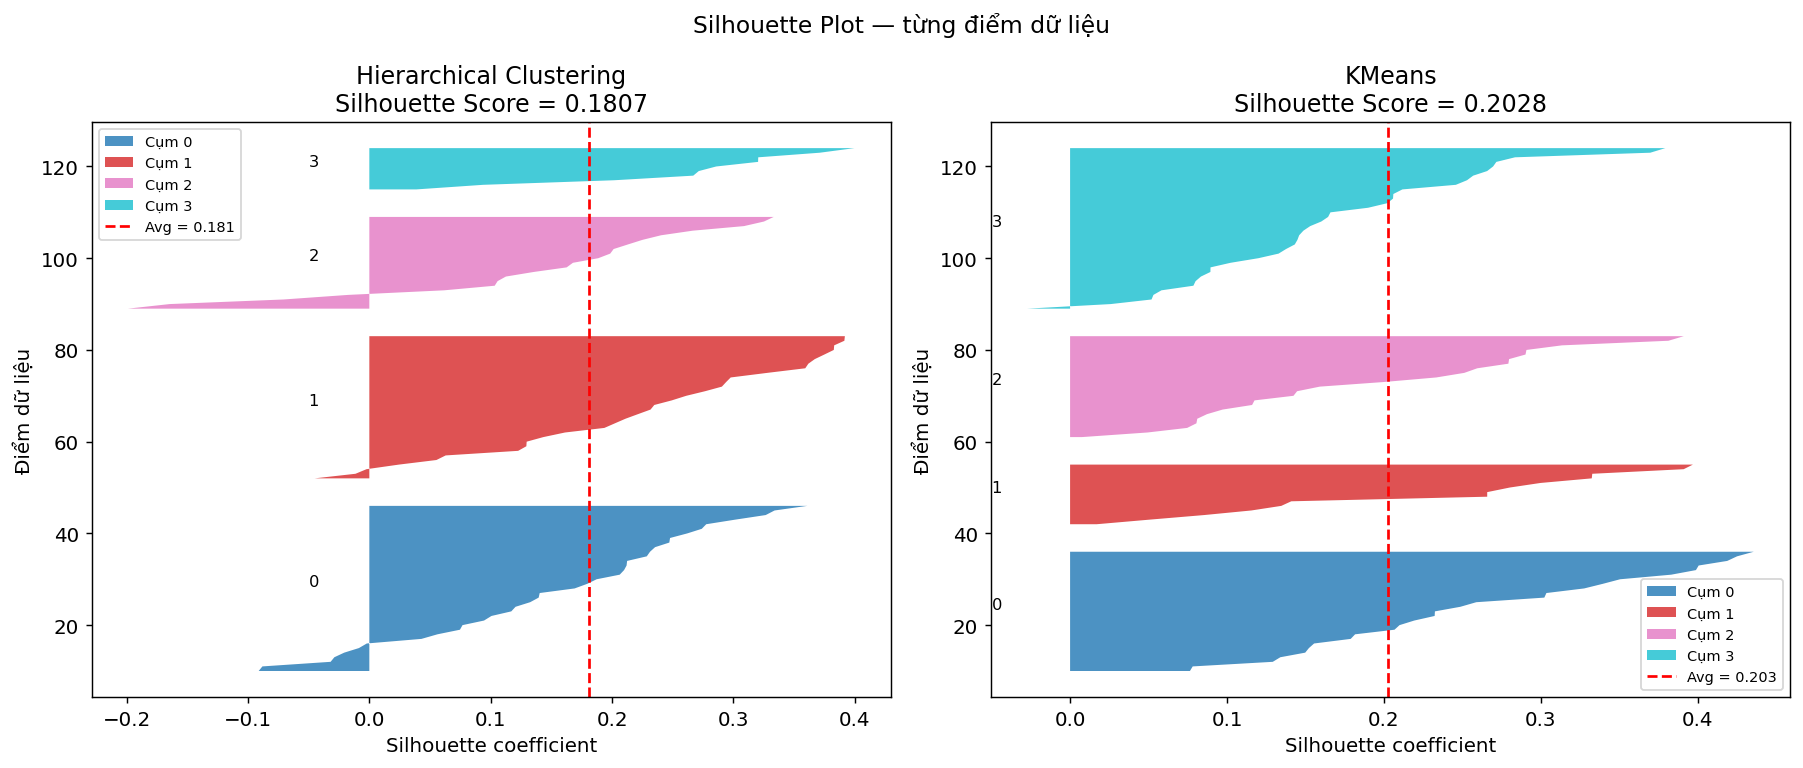

In [21]:
# =====================================================
# CELL 12 — SILHOUETTE PLOT CHI TIẾT
# Xem từng điểm phân tách tốt không
# =====================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Silhouette Plot — từng điểm dữ liệu', fontsize=13)

for ax, (labels, title) in zip(axes, [
    (df['Cluster_HC'].values, 'Hierarchical Clustering'),
    (df['Cluster_KM'].values, 'KMeans'),
]):
    sil_vals = silhouette_samples(X, labels)
    sil_avg  = silhouette_score(X, labels)

    y_lower = 10
    n_clusters = len(np.unique(labels))
    cmap = plt.cm.get_cmap('tab10', n_clusters)

    for i in range(n_clusters):
        ith_vals = np.sort(sil_vals[labels == i])
        size = ith_vals.shape[0]
        y_upper = y_lower + size
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_vals,
                         facecolor=cmap(i), alpha=0.8, label=f'Cụm {i}')
        ax.text(-0.05, y_lower + 0.5 * size, str(i), fontsize=9)
        y_lower = y_upper + 5

    ax.axvline(sil_avg, color='red', linestyle='--', linewidth=1.5,
               label=f'Avg = {sil_avg:.3f}')
    ax.set_title(f'{title}\nSilhouette Score = {sil_avg:.4f}')
    ax.set_xlabel('Silhouette coefficient')
    ax.set_ylabel('Điểm dữ liệu')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../reports/silhouette_plot.png', dpi=150)
plt.show()

  Silhouette — Hierarchical : 0.1807
  Silhouette — KMeans       : 0.2028
  Thuật toán tốt hơn: KMeans

Mapping HC:
{np.int64(3): 'Bán chạy', np.int64(2): 'Bán chậm', np.int64(1): 'Tồn kho cao', 0: 'Ổn định'}

Mapping KMeans:
{np.int32(1): 'Bán chạy', np.int32(2): 'Bán chậm', np.int32(0): 'Tồn kho cao', 3: 'Ổn định'}


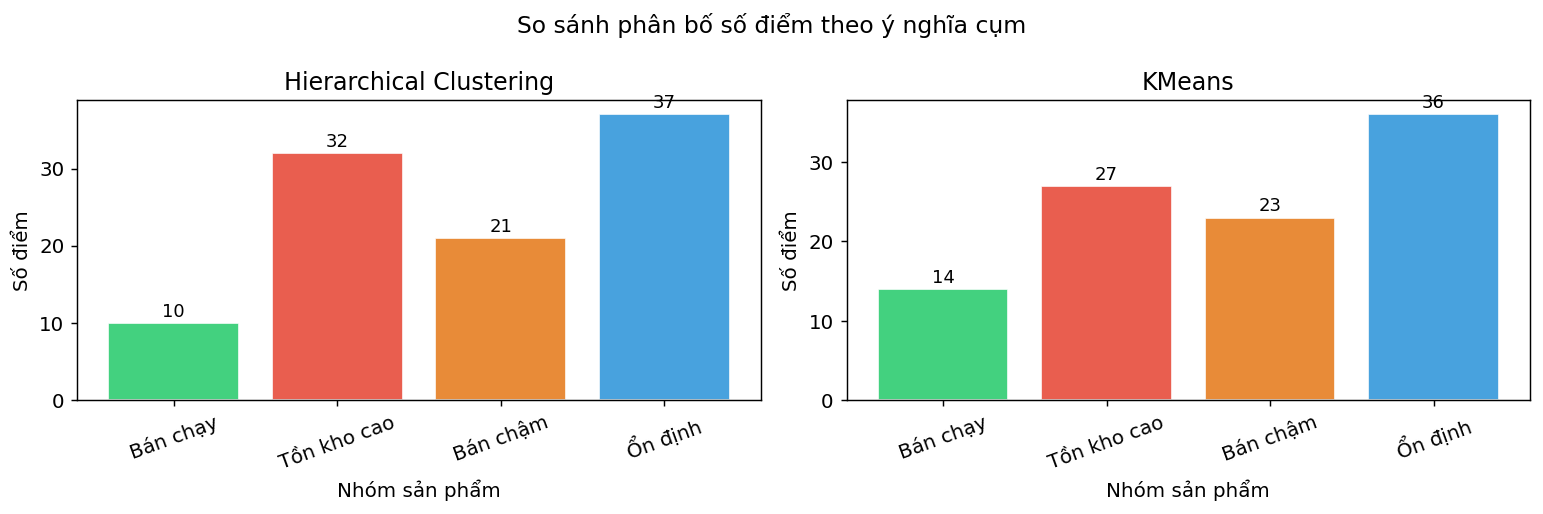

In [29]:
# =====================================================
# CELL 13 — SO SÁNH HC vs KMEANS + MAP TÊN CỤM ĐÚNG
# =====================================================

from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import pandas as pd

# 1. Tính Silhouette
sil_hc = silhouette_score(X, df['Cluster_HC'].values)
sil_km = silhouette_score(X, df['Cluster_KM'].values)

print("=" * 45)
print(f"  Silhouette — Hierarchical : {sil_hc:.4f}")
print(f"  Silhouette — KMeans       : {sil_km:.4f}")
print("=" * 45)
print(f"  Thuật toán tốt hơn: {'Hierarchical' if sil_hc > sil_km else 'KMeans'}")

# 2. Các feature dùng để phân tích ý nghĩa cụm
feature_cols = [
    'total_sales',
    'sale_frequency',
    'revenue',
    'sales_variance',
    'avg_inventory',
    'stock_turnover',
    'fill_rate'
]

# 3. Hàm tự đặt tên cụm dựa trên profile trung bình
def assign_cluster_names(profile):
    """
    profile: dataframe index = cluster id, columns = feature_cols
    Trả về dict: {cluster_id: cluster_name}
    """

    mapping = {}

    # Bán chạy: doanh số + doanh thu + vòng quay tồn kho cao nhất
    score_fast = (
        profile['total_sales'] +
        profile['revenue'] +
        profile['stock_turnover'] +
        profile['fill_rate']
    )
    fast_cluster = score_fast.idxmax()
    mapping[fast_cluster] = 'Bán chạy'

    # Bán chậm: doanh số + doanh thu + tần suất bán thấp nhất
    score_slow = (
        profile['total_sales'] +
        profile['revenue'] +
        profile['sale_frequency']
    )
    available = [c for c in profile.index if c not in mapping]
    slow_cluster = score_slow.loc[available].idxmin()
    mapping[slow_cluster] = 'Bán chậm'

    # Tồn kho cao: tồn kho cao, nhưng vòng quay không tương xứng
    score_inventory = (
        profile['avg_inventory'] - profile['stock_turnover']
    )
    available = [c for c in profile.index if c not in mapping]
    inventory_cluster = score_inventory.loc[available].idxmax()
    mapping[inventory_cluster] = 'Tồn kho cao'

    # Còn lại là ổn định
    for c in profile.index:
        if c not in mapping:
            mapping[c] = 'Ổn định'

    return mapping


# 4. Profile trung bình của HC và KMeans
profile_hc = df.groupby('Cluster_HC')[feature_cols].mean()
profile_km = df.groupby('Cluster_KM')[feature_cols].mean()

# 5. Map tên cụm đúng cho từng thuật toán
hc_name_map = assign_cluster_names(profile_hc)
km_name_map = assign_cluster_names(profile_km)

print("\nMapping HC:")
print(hc_name_map)

print("\nMapping KMeans:")
print(km_name_map)

# 6. Gán tên cụm vào dataframe
df['Cluster_HC_Name'] = df['Cluster_HC'].map(hc_name_map)
df['Cluster_KM_Name'] = df['Cluster_KM'].map(km_name_map)

# 7. Màu cố định theo Ý NGHĨA cụm, không theo số cụm
NAME_COLORS = {
    'Bán chạy': '#2ecc71',     # xanh lá
    'Tồn kho cao': '#e74c3c',  # đỏ
    'Bán chậm': '#e67e22',     # cam
    'Ổn định': '#3498db'       # xanh dương
}

ORDER = ['Bán chạy', 'Tồn kho cao', 'Bán chậm', 'Ổn định']

# 8. Đếm số điểm theo tên cụm
hc_counts = df['Cluster_HC_Name'].value_counts().reindex(ORDER, fill_value=0)
km_counts = df['Cluster_KM_Name'].value_counts().reindex(ORDER, fill_value=0)

# 9. Vẽ biểu đồ so sánh đã map đúng ý nghĩa
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('So sánh phân bố số điểm theo ý nghĩa cụm', fontsize=13)

for ax, counts, title in zip(
    axes,
    [hc_counts, km_counts],
    ['Hierarchical Clustering', 'KMeans']
):
    bars = ax.bar(
        counts.index,
        counts.values,
        color=[NAME_COLORS[name] for name in counts.index],
        edgecolor='white',
        alpha=0.9
    )

    for bar, v in zip(bars, counts.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            str(v),
            ha='center',
            va='bottom',
            fontsize=10
        )

    ax.set_title(title)
    ax.set_xlabel('Nhóm sản phẩm')
    ax.set_ylabel('Số điểm')
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('../reports/cluster_size_comparison_mapped.png', dpi=150)
plt.show()

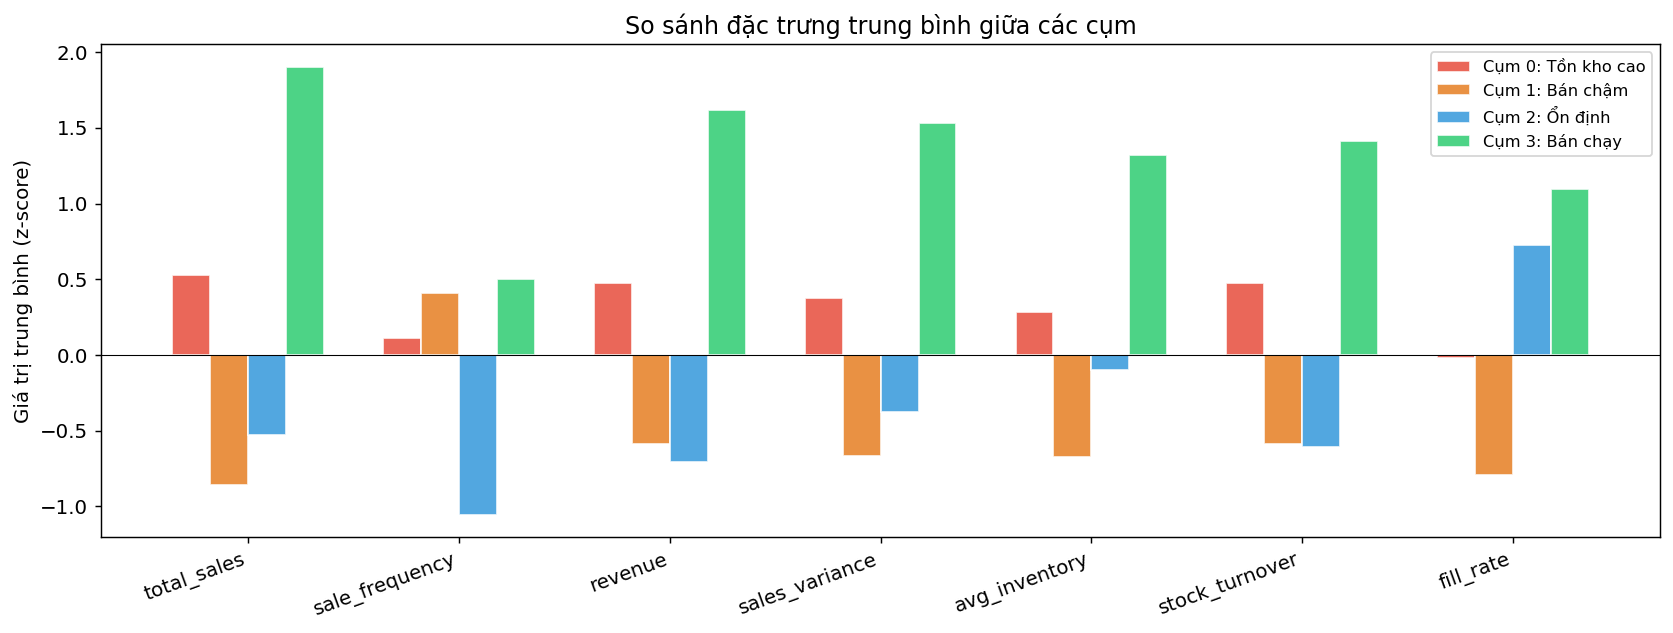

            total_sales  sale_frequency  revenue  sales_variance  \
Cluster_HC                                                         
0                  0.53            0.11     0.47            0.38   
1                 -0.86            0.41    -0.59           -0.67   
2                 -0.53           -1.06    -0.71           -0.38   
3                  1.90            0.50     1.62            1.53   

            avg_inventory  stock_turnover  fill_rate  
Cluster_HC                                            
0                    0.28            0.47      -0.02  
1                   -0.67           -0.59      -0.79  
2                   -0.10           -0.61       0.72  
3                    1.32            1.41       1.10  


In [28]:

# =====================================================
# CELL 14 — PHÂN TÍCH CHI TIẾT TỪNG CỤM (HC)
# Biểu đồ bar chart so sánh đặc trưng trung bình
# =====================================================

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(feature_cols))
w = 0.18

for i, cid in enumerate(cluster_profile.index):
    name  = cluster_names[cid]
    color = colors[name]  # lấy màu từ COLORS dict → thống nhất toàn bộ notebook
    ax.bar(x + i*w, cluster_profile.loc[cid], width=w,
           label=f'Cụm {cid}: {name}', color=color, alpha=0.85, edgecolor='white')

ax.set_xticks(x + 1.5*w)
ax.set_xticklabels(feature_cols, rotation=20, ha='right')
ax.axhline(0, color='black', linewidth=0.6)
ax.set_ylabel('Giá trị trung bình (z-score)')
ax.set_title('So sánh đặc trưng trung bình giữa các cụm')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../reports/cluster_feature_comparison.png', dpi=150)
plt.show()

print(cluster_profile.round(2))

In [25]:
# =====================================================
# CELL 15 — LƯU KẾT QUẢ
# =====================================================

output = df[['product_id', 'store_id', 'Cluster_HC', 'Cluster_KM', 'Cluster_Name']].copy()
output.to_csv('../data/processed/clustering_results.csv', index=False)

print("Đã lưu kết quả clustering!")
print("\nMẫu kết quả:")
print(output.head(10))
print(f"\nPhân bố nhãn cụm:")
print(output['Cluster_Name'].value_counts())

Đã lưu kết quả clustering!

Mẫu kết quả:
  product_id store_id  Cluster_HC  Cluster_KM Cluster_Name
0      P0001     S001           0           3  Tồn kho cao
1      P0001     S002           3           1     Bán chạy
2      P0001     S003           1           0     Bán chậm
3      P0001     S004           0           3  Tồn kho cao
4      P0001     S005           1           0     Bán chậm
5      P0002     S001           1           0     Bán chậm
6      P0002     S002           1           0     Bán chậm
7      P0002     S003           2           2      Ổn định
8      P0002     S004           1           0     Bán chậm
9      P0002     S005           1           3     Bán chậm

Phân bố nhãn cụm:
Cluster_Name
Tồn kho cao    37
Bán chậm       32
Ổn định        21
Bán chạy       10
Name: count, dtype: int64
